# 🧠 PyTorch 딥러닝 실습 — MNIST 손글씨 분류

---

### 실습 목표
- PyTorch로 간단한 신경망을 만들어 본다
- 손글씨 숫자(0~9) 이미지를 자동으로 분류하는 AI를 학습시킨다
- 순전파 → 손실 계산 → 역전파 → 업데이트 사이클을 직접 체험한다

### 사전 준비
1. **GPU 켜기**: 상단 메뉴 → `런타임` → `런타임 유형 변경` → 하드웨어 가속기를 **T4 GPU**로 선택 → 저장
2. 각 셀을 **위에서 아래로 순서대로** 실행하세요 (▶️ 버튼 또는 `Shift + Enter`)

---
## ⚡ Step 0. GPU 연결 확인

In [1]:
# ============================================================
# ⚡ GPU 연결 확인
# ============================================================
# 이 셀을 실행해서 GPU가 잘 연결되었는지 확인하자!
# "GPU 사용 가능: True"가 나오면 성공!
# ============================================================

import torch

# GPU가 사용 가능한지 확인
# True → GPU 정상 연결 / False → GPU가 꺼져 있음
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

# 어떤 GPU가 연결되었는지 이름 확인
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    print("✅ GPU가 정상적으로 연결되었습니다!")
else:
    print("⚠️ GPU가 연결되지 않았습니다!")
    print("  → 상단 메뉴 > 런타임 > 런타임 유형 변경 > T4 GPU 선택 후 저장해 주세요")
    print("  → CPU로도 실행은 가능하지만, 학습이 좀 더 느릴 수 있습니다")

GPU 사용 가능: True
GPU 이름: Tesla T4
✅ GPU가 정상적으로 연결되었습니다!


---
## 📦 Step 1. 라이브러리 불러오기

In [2]:
# ============================================================
# 📦 필요한 도구들 불러오기
# ============================================================
# Colab에는 PyTorch가 이미 설치되어 있어서
# 별도 설치(pip install) 없이 바로 import 하면 된다!
# ============================================================

# torch: PyTorch의 핵심 라이브러리
# 텐서(다차원 배열) 연산, 자동 미분 등을 담당한다
import torch

# torch.nn: 신경망을 만들 때 필요한 도구 모음
# Linear(층), ReLU(활성화 함수), Dropout 등이 들어있다
import torch.nn as nn

# torch.optim: 옵티마이저(가중치 업데이트 방법) 모음
# Adam, SGD 등이 들어있다
import torch.optim as optim

# torchvision.datasets: MNIST 같은 유명한 데이터셋을 쉽게 다운로드하는 도구
# torchvision.transforms: 이미지를 텐서로 바꾸거나 정규화하는 전처리 도구
from torchvision import datasets, transforms

# DataLoader: 데이터를 배치(묶음) 단위로 잘라서 모델에 넣어주는 도구
# 비유: 한 번에 64장씩 넣어주는 컨베이어 벨트!
from torch.utils.data import DataLoader

# matplotlib: 그래프나 이미지를 시각화할 때 사용하는 라이브러리
import matplotlib.pyplot as plt

print("✅ 모든 라이브러리를 성공적으로 불러왔습니다!")

✅ 모든 라이브러리를 성공적으로 불러왔습니다!


---
## 📂 Step 2. MNIST 데이터 불러오기

MNIST = 0~9까지 **손으로 쓴 숫자** 이미지 7만 장
- 학습용 60,000장 (교과서)
- 테스트용 10,000장 (시험지)
- 각 이미지는 28×28 픽셀 흑백

In [31]:
# ============================================================
# 📂 MNIST 데이터셋 준비하기
# ============================================================

# --- 전처리(Transform) 정의 ---
# 이미지를 모델이 이해할 수 있는 형태로 변환하는 과정
# Compose: 여러 전처리를 순서대로 묶어서 한 번에 적용
transform = transforms.Compose([

    # ① ToTensor(): 이미지를 PyTorch 텐서로 변환
    #    - 원래 픽셀 값은 0~255 (밝기)
    #    - 텐서로 바꾸면 자동으로 0.0~1.0 범위로 변환됨
    transforms.ToTensor(),

    # ② Normalize(): 데이터의 분포를 조정
    #    - (0.5,)는 평균, (0.5,)는 표준편차
    #    - 이렇게 하면 값의 범위가 0.0~1.0 → -1.0~1.0으로 바뀜
    #    - 왜 하는 걸까?
    #      값이 0 근처에 모여 있으면 학습이 더 안정적이고 빨라지기 때문!
    #      (비유: 시소의 중심을 0에 맞추면 균형이 잘 잡히는 것과 비슷)
    transforms.Normalize((0.5,), (0.5,))
])

# --- 학습용 데이터셋 다운로드 ---
# train=True : 학습용 데이터 60,000장 (모델이 공부하는 교과서)
# download=True : 처음 실행할 때 자동으로 다운로드 (이미 있으면 건너뜀)
train_dataset = datasets.MNIST(
    root='./data',        # 다운로드할 경로 (./data 폴더에 저장)
    train=True,           # 학습용 데이터
    download=True,        # 자동 다운로드
    transform=transform   # 위에서 정의한 전처리 적용
)

# --- 테스트용 데이터셋 다운로드 ---
# train=False : 테스트용 데이터 10,000장 (진짜 실력을 확인하는 시험지)
# 주의: 학습에는 절대 사용하지 않는다! 오직 평가용!
test_dataset = datasets.MNIST(
    root='./data',
    train=False,          # 테스트용 데이터
    download=True,
    transform=transform
)

# --- DataLoader 만들기 ---
# DataLoader = 데이터를 배치(묶음) 단위로 잘라서 모델에 공급하는 컨베이어 벨트
# 왜 배치로 나눌까? 60,000장을 한꺼번에 넣으면 메모리가 터진다!
# 그래서 64장씩 나눠서 조금씩 학습한다

train_loader = DataLoader(
    train_dataset,        # 어떤 데이터셋을 쓸 것인지
    batch_size=64,        # 한 번에 64장씩 묶어서 전달
    shuffle=True          # 매 에포크마다 순서를 랜덤으로 섞음
                          # → 순서에 의존하지 않고 골고루 학습하기 위해!
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False         # 테스트할 때는 섞을 필요 없음
)

# --- 잘 불러왔는지 확인 ---
print(f"✅ 학습 데이터: {len(train_dataset)}장")
print(f"✅ 테스트 데이터: {len(test_dataset)}장")
print(f"   이미지 크기: 28 × 28 픽셀 (흑백)")
print(f"   배치 사이즈: 64장씩")
print(f"   학습 배치 수: {len(train_loader)}개 (= 60,000 ÷ 64)")

✅ 학습 데이터: 60000장
✅ 테스트 데이터: 10000장
   이미지 크기: 28 × 28 픽셀 (흑백)
   배치 사이즈: 64장씩
   학습 배치 수: 938개 (= 60,000 ÷ 64)


# FachionMNIST로 데이터 변경
단순히 데이터만 적용하였을 때에는 정확도가 88.23%로 낮게 나왔다.
여기에 1번의 CNN 모델을 적용하니 정확도가 90.95%가 나왔다.

이미지 데이터이기 때문에 CNN모델과 함께 사용했을 때 정확도가 훨씬 높게 나왔다.

In [64]:
# 1. 데이터 전처리 설정 (텐서 변환 및 정규화)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. 학습용 데이터 다운로드 (train=True)
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# 3. 테스트용 데이터 다운로드 (train=False)
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 4. DataLoader 만들기 (test_loader가 test_dataset을 보도록 확실히 지정!)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # 👈 test_dataset 확인!

# 잘 불러왔는지 확인
print(f"✅ 학습 데이터(옷): {len(train_dataset)}장")
print(f"✅ 테스트 데이터(옷): {len(test_dataset)}장")

✅ 학습 데이터(옷): 60000장
✅ 테스트 데이터(옷): 10000장


# 배치사이즈를 16으로 바꾼 결과, 학습 시간이 길어졌다.
# 배치 사이즈를 256으로 바꾼 결과, 학습 시간이 줄었으며 학습 곡선도 잘 표현되었다.

---
## 👀 Step 3. 데이터 미리보기

실제로 MNIST 데이터가 어떻게 생겼는지 눈으로 확인해보자!

/tmp/ipykernel_8056/1330008074.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/1330008074.py:26: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


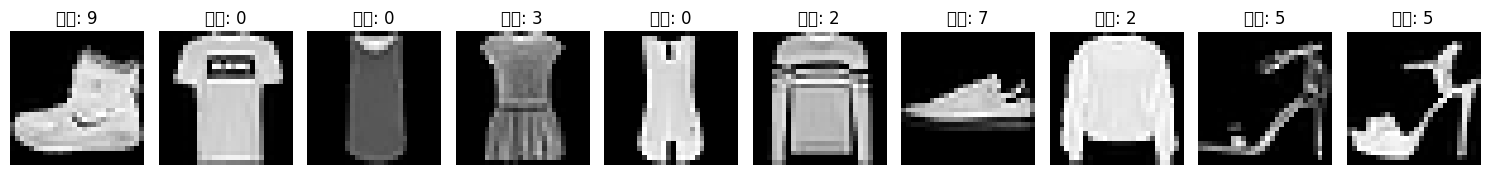


💡 위 이미지들이 28×28 픽셀 흑백 손글씨 숫자입니다!
   이런 이미지를 보고 0~9 중 어떤 숫자인지 맞추는 AI를 만들 거예요.


In [65]:
# ============================================================
# 👀 MNIST 데이터 미리보기
# ============================================================
# 학습 데이터에서 이미지 10장을 뽑아서 어떻게 생겼는지 확인!
# ============================================================

# 그림을 그릴 도화지 준비 (가로로 10장 나란히)
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for i in range(10):
    # train_dataset[i] → i번째 데이터를 꺼냄
    # 반환값: (이미지 텐서, 정답 숫자)
    image, label = train_dataset[i]

    # image.squeeze() : 불필요한 차원 제거 (1×28×28 → 28×28)
    # cmap='gray' : 흑백으로 표시
    axes[i].imshow(image.squeeze(), cmap='gray')

    # 이미지 위에 정답 숫자 표시
    axes[i].set_title(f"정답: {label}")

    # 축 눈금 숨기기 (깔끔하게 보이도록)
    axes[i].axis('off')

# 그림 간격 자동 조절
plt.tight_layout()

# 화면에 표시 (Colab에서는 셀 아래에 바로 그림이 나타난다!)
plt.show()

print("\n💡 위 이미지들이 28×28 픽셀 흑백 손글씨 숫자입니다!")
print("   이런 이미지를 보고 0~9 중 어떤 숫자인지 맞추는 AI를 만들 거예요.")

---
## 🏗️ Step 4. 신경망 모델 만들기

이제 실제로 숫자를 분류할 **인공신경망**을 만들어보자!

구조:
```
입력 (784개 픽셀) → 은닉층1 (256개) → 은닉층2 (128개) → 출력 (10개: 숫자 0~9)
```

In [58]:
# ============================================================
# 🏗️ 신경망 모델 정의하기
# ============================================================
# PyTorch에서 모델을 만드는 방법:
#   1. nn.Module을 상속받는 클래스를 만든다
#   2. __init__에서 사용할 층(layer)들을 선언한다
#   3. forward에서 데이터가 통과하는 순서를 정의한다
# ============================================================

class MNISTClassifier(nn.Module):

    def __init__(self):
        # 부모 클래스(nn.Module)의 초기화 함수를 먼저 호출
        # PyTorch가 내부적으로 필요한 설정들을 자동으로 해줌
        # (이 줄은 항상 써줘야 하는 '주문'이라고 생각하면 됨!)
        super().__init__()

        # ─── Flatten ───
        # 2D 이미지(28×28)를 1D 벡터(784)로 쭉 펼치기
        # 왜? Linear 층은 1차원 입력만 받을 수 있기 때문!
        # 비유: 2D 퍼즐 조각을 한 줄로 쭉 늘어놓는 것
        self.flatten = nn.Flatten()

        # ─── Sequential: 층을 순서대로 쌓는 컨테이너 ───
        self.network = nn.Sequential(

            # ▸ 첫 번째 은닉층: 784개 입력 → 256개 출력
            #   784개의 픽셀 정보를 256개의 "특징"으로 압축하는 과정
            #   (Linear = 완전연결층: 모든 입력이 모든 출력과 연결됨)
            nn.Linear(784, 256),

            # ▸ ReLU 활성화 함수
            #   음수 → 0으로 바꿈 / 양수 → 그대로 통과
            #   왜 필요할까? 이게 없으면 아무리 층을 쌓아도
            #   결국 단순한 직선(y=ax+b)밖에 못 그린다!
            #   ReLU가 있어야 복잡한 곡선(패턴)을 학습할 수 있음
            nn.ReLU(),

            # ▸ Dropout: 학습 중 뉴런의 20%를 랜덤으로 꺼버리기
            #   왜? 과적합(외워버리기)을 방지하기 위해!
            #   비유: 스터디에서 매번 다른 멤버가 빠져도
            #         나머지가 해결할 수 있게 훈련하는 것
            #   → 특정 뉴런에 의존하지 않는 튼튼한 모델이 만들어진다
            nn.Dropout(0.2),

            # ▸ 두 번째 은닉층: 256개 → 128개로 더 압축
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            # ▸ 출력층: 128개 → 10개
            #   10개 = 숫자 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
            #   각 출력 뉴런의 값이 클수록
            #   "이 숫자일 가능성이 높다"는 뜻!
            nn.Linear(128, 10)
        )

    def forward(self, x):
        # forward = 데이터가 모델을 통과하는 순서 정의
        # x: 입력 이미지 텐서 (배치크기 × 1 × 28 × 28)

        x = self.flatten(x)     # Step A: 28×28 → 784로 펼치기
        x = self.network(x)     # Step B: 신경망 층들을 순서대로 통과
        return x                # Step C: 10개 숫자에 대한 점수 반환


# ─── 디바이스(GPU/CPU) 설정 ───
# GPU가 있으면 GPU를 쓰고, 없으면 CPU를 쓴다
# GPU는 행렬 연산에 특화되어 있어서 딥러닝 학습이 훨씬 빠르다!
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

# ─── 모델 생성 ───
# 모델 객체를 만들고, GPU(또는 CPU)로 보낸다
# .to(device): 모델의 모든 가중치를 해당 디바이스로 이동
model = MNISTClassifier().to(device)

# 모델 구조 출력 (어떤 층이 있는지 한눈에 볼 수 있다!)
print("\n📐 모델 구조:")
print(model)

# ─── 모델의 파라미터(가중치) 개수 세기 ───
# 총 몇 개의 숫자(가중치)를 학습시키는지 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"\n🔢 총 학습 가능한 파라미터 수: {total_params:,}개")
print(f"   → 이 {total_params:,}개의 숫자를 조금씩 조절하는 게 '학습'이다!")

사용 디바이스: cuda

📐 모델 구조:
MNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

🔢 총 학습 가능한 파라미터 수: 235,146개
   → 이 235,146개의 숫자를 조금씩 조절하는 게 '학습'이다!


# CNN모델으로 변경해보기

결과 : 정확도가 97.41 -> 98.62% 로 상승되었다.

In [66]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        # ─── 특징 추출 (CNN 층) ───
        self.features = nn.Sequential(
            # 1채널(흑백) 입력 -> 16채널 특징맵 생성 (크기는 28x28 유지)
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            # 이미지 크기를 절반으로 줄임 (28x28 -> 14x14)
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # ─── 분류 (Linear 층) ───
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10) # 10개 클래스
        )

    def forward(self, x):
        # x는 펴지 않고 바로 2D 형태 그대로 features(CNN)에 들어갑니다.
        x = self.features(x)
        x = self.classifier(x)
        return x

# ─── 디바이스 및 모델 생성 ───
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

# 기존 MNISTClassifier 대신 CNNClassifier로 변경!
model = CNNClassifier().to(device)

print("\n 모델 구조:")
print(model)

사용 디바이스: cuda

 모델 구조:
CNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


---
## ⚙️ Step 5. 손실 함수 & 옵티마이저 설정

- **손실 함수**: 모델이 얼마나 틀렸는지 점수 매기는 채점 기준
- **옵티마이저**: 그 점수를 보고 가중치를 어떻게 수정할지 결정하는 전략

In [67]:
# ============================================================
# ⚙️ 학습에 필요한 도구 설정
# ============================================================

# ─── 손실 함수 (Loss Function) ───
# CrossEntropyLoss: 분류 문제에서 가장 많이 쓰이는 손실 함수
# "정답 클래스의 확률을 얼마나 높게 줬느냐"를 기준으로 채점한다
#
# 예시:
#   정답이 "3"인데 모델이 3번 출력을 높게 줬으면 → 손실 작음 (잘했다!)
#   정답이 "3"인데 모델이 7번 출력을 높게 줬으면 → 손실 큼 (틀렸다!)
criterion = nn.CrossEntropyLoss()

# ─── 옵티마이저 (Optimizer) ───
# Adam: 현재 가장 널리 쓰이는 옵티마이저
#   - 학습률을 자동으로 조절해주는 똑똑한 방식
#   - 비유: 산을 내려갈 때 경험을 기억하면서 효율적으로 내려가는 등산객
#
# model.parameters(): 모델 안의 모든 가중치를 옵티마이저에게 알려줌
#   → "이 가중치들을 학습시켜줘!" 라고 등록하는 것
#
# lr=0.001: 학습률 (Learning Rate) = 한 번에 얼마나 크게 수정할지
#   → 0.001은 Adam의 기본값이자 가장 흔한 시작점
#   → 너무 크면 최적점을 지나침, 너무 작으면 학습이 너무 느림
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ 손실 함수: CrossEntropyLoss (분류용)")
print("✅ 옵티마이저: Adam (lr=0.001)")
print("\n준비 완료! 이제 학습을 시작하겠습니다 🚀")

✅ 손실 함수: CrossEntropyLoss (분류용)
✅ 옵티마이저: Adam (lr=0.001)

준비 완료! 이제 학습을 시작하겠습니다 🚀


# 학습률 (Learning Rate) 바꿔보기

lr = 0.01일 때는 학습 곡선이 위아래로 요동치는 형태를 보이며 정확도가 92.68%로 떨어졌다.

lr = 0.0001일 때는 학습 곡선 속 손실이 느리게 떨어지는 형태를 보인다. 하지만 정확도는 비슷하였다.

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

---
## 🏋️ Step 6. 모델 학습시키기

드디어 핵심! 아래 사이클을 수천 번 반복한다:

```
① 순전파: 이미지를 모델에 넣어서 예측값을 얻는다
② 손실 계산: 예측값과 정답을 비교해서 "얼마나 틀렸는지" 점수를 매긴다
③ 역전파: 거꾸로 추적하면서 "어떤 가중치가 틀림에 기여했는지" 계산한다
④ 업데이트: 문제가 된 가중치를 조금 수정한다
```

⏱️ GPU 기준 약 1~2분 소요됩니다.

In [68]:
# ============================================================
# 🏋️ 학습 루프 (Training Loop)
# ============================================================
# 이 부분이 딥러닝의 핵심!
# "순전파 → 손실 계산 → 역전파 → 가중치 업데이트"를 반복한다
# ============================================================

# 전체 데이터를 몇 번 반복해서 학습할 것인지
# 비유: 교과서를 10번 반복해서 읽는 것
EPOCHS = 10

# 에포크별 손실을 기록 (나중에 그래프 그리기 위해)
loss_history = []

print("🏋️ 학습을 시작합니다!\n")

for epoch in range(EPOCHS):

    # ─── 학습 모드 켜기 ───
    # model.train()을 호출하면:
    #   - Dropout이 활성화됨 (뉴런 20%를 랜덤으로 끔)
    #   - BatchNorm 등도 학습 모드로 동작
    # (테스트할 때는 model.eval()로 전환해야 함!)
    model.train()

    # 이번 에포크의 총 손실을 기록할 변수
    total_loss = 0

    # ─── 배치 단위로 학습 ───
    # train_loader가 데이터를 64장씩 묶어서 전달해준다
    for images, labels in train_loader:
        # images: 이미지 64장이 담긴 텐서 (크기: 64 × 1 × 28 × 28)
        # labels: 각 이미지의 정답 숫자 64개 (예: [5, 0, 4, 1, ...])

        # 데이터를 GPU(또는 CPU)로 보내기
        # 모델이 GPU에 있으면 데이터도 GPU에 있어야 연산 가능!
        images = images.to(device)
        labels = labels.to(device)

        # ============================================
        # ★ STEP 1: 순전파 (Forward Pass)
        # ============================================
        # 이미지를 모델에 넣으면
        # 10개 클래스(0~9)에 대한 점수(logits)가 나온다
        # 예: [0.1, -0.5, 0.3, 2.8, ...] → 3번(숫자 3)이 가장 높음
        outputs = model(images)

        # ============================================
        # ★ STEP 2: 손실 계산
        # ============================================
        # 모델의 예측(outputs)과 정답(labels)을 비교
        # → 얼마나 틀렸는지 숫자 하나(loss)로 나옴
        # 이 숫자가 작을수록 잘 맞추고 있다는 뜻!
        loss = criterion(outputs, labels)

        # ============================================
        # ★ STEP 3: 이전 그래디언트 초기화
        # ============================================
        # 왜 필요할까?
        # PyTorch는 기본적으로 그래디언트를 '누적'한다.
        # 그래서 매번 새로 계산하려면 먼저 0으로 리셋해야 함!
        # (안 하면 이전 배치의 그래디언트가 섞여서 엉망이 됨)
        optimizer.zero_grad()

        # ============================================
        # ★ STEP 4: 역전파 (Backward Pass)
        # ============================================
        # 손실(loss)을 기준으로 거꾸로 추적하면서
        # "각 가중치가 이 손실에 얼마나 기여했는지" 계산
        # = 그래디언트(gradient) 계산
        # PyTorch가 자동으로 해줌! (자동 미분, autograd)
        loss.backward()

        # ============================================
        # ★ STEP 5: 가중치 업데이트
        # ============================================
        # 계산된 그래디언트를 이용해서 가중치를 조금씩 수정
        # 손실이 줄어드는 방향으로 가중치를 조절한다!
        # (옵티마이저가 알아서 최적의 방법으로 업데이트)
        optimizer.step()

        # 이번 배치의 손실을 누적
        # .item(): 텐서에서 파이썬 숫자로 변환
        total_loss += loss.item()

    # ─── 에포크 결과 출력 ───
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)  # 나중에 그래프 그리기 위해 저장

    print(f"  Epoch [{epoch+1:2d}/{EPOCHS}] | 평균 손실: {avg_loss:.4f}")

print("\n✅ 학습 완료!")
print("   손실이 점점 줄어들었다면 → 학습이 잘 된 것입니다! 🎉")

🏋️ 학습을 시작합니다!

  Epoch [ 1/10] | 평균 손실: 0.4760
  Epoch [ 2/10] | 평균 손실: 0.3198
  Epoch [ 3/10] | 평균 손실: 0.2787
  Epoch [ 4/10] | 평균 손실: 0.2536
  Epoch [ 5/10] | 평균 손실: 0.2333
  Epoch [ 6/10] | 평균 손실: 0.2186
  Epoch [ 7/10] | 평균 손실: 0.2021
  Epoch [ 8/10] | 평균 손실: 0.1894
  Epoch [ 9/10] | 평균 손실: 0.1818
  Epoch [10/10] | 평균 손실: 0.1686

✅ 학습 완료!
   손실이 점점 줄어들었다면 → 학습이 잘 된 것입니다! 🎉


---
## 📉 Step 7. 학습 곡선 확인하기

에포크가 진행될수록 손실이 줄어드는지 그래프로 확인해보자!

/tmp/ipykernel_8056/2336141208.py:22: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/2336141208.py:22: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/2336141208.py:22: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/2336141208.py:22: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/2336141208.py:22: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/2336141208.py:22: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/2336141208.py:22: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_

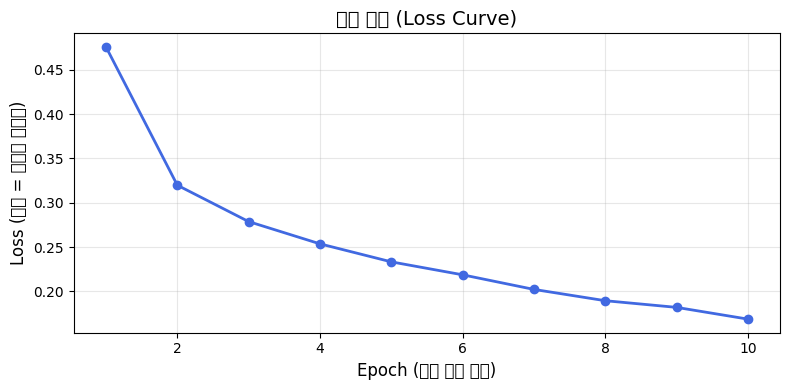

💡 그래프가 오른쪽 아래로 내려가면 학습이 잘 된 것!
   첫 에포크 손실: 0.4760 → 마지막 에포크 손실: 0.1686


In [69]:
# ============================================================
# 📉 학습 곡선 (Loss Curve) 그리기
# ============================================================
# 에포크가 진행될수록 손실이 줄어들면 → 학습이 잘 되고 있다는 뜻!
# ============================================================

plt.figure(figsize=(8, 4))

# x축: 에포크 번호 (1부터 시작), y축: 평균 손실
plt.plot(
    range(1, EPOCHS + 1),   # x축: 1, 2, 3, ..., 10
    loss_history,            # y축: 각 에포크의 평균 손실
    marker='o',              # 각 점에 동그라미 표시
    color='royalblue',       # 선 색상
    linewidth=2              # 선 두께
)

plt.title('학습 곡선 (Loss Curve)', fontsize=14)
plt.xlabel('Epoch (학습 반복 횟수)', fontsize=12)
plt.ylabel('Loss (손실 = 얼마나 틀렸나)', fontsize=12)
plt.grid(True, alpha=0.3)   # 배경에 격자 표시 (보기 쉽게)
plt.tight_layout()
plt.show()

print("💡 그래프가 오른쪽 아래로 내려가면 학습이 잘 된 것!")
print(f"   첫 에포크 손실: {loss_history[0]:.4f} → 마지막 에포크 손실: {loss_history[-1]:.4f}")

---
## 📊 Step 8. 테스트 — 진짜 실력 확인하기

학습에 **한 번도 사용하지 않은** 테스트 데이터 10,000장으로 실력을 측정한다.

비유: 교과서(학습 데이터)로 공부한 뒤, 처음 보는 시험지(테스트 데이터)를 푸는 것!

In [70]:
# ============================================================
# 📊 테스트: 한 번도 본 적 없는 데이터로 실력 측정
# ============================================================

# ─── 평가 모드 켜기 ───
# model.eval()을 호출하면:
#   - Dropout이 꺼진다 (모든 뉴런이 참여)
#   - 학습 때는 일부를 끄고 연습했지만, 시험에서는 전부 사용!
model.eval()

correct = 0  # 맞춘 개수
total = 0    # 전체 개수

# ─── 그래디언트 계산 끄기 ───
# torch.no_grad(): 그래디언트(미분) 계산을 하지 않겠다는 뜻
# 테스트할 때는 가중치를 업데이트하지 않으므로 그래디언트가 필요 없다!
# → 메모리 절약 + 속도 향상
with torch.no_grad():

    for images, labels in test_loader:
        # 데이터를 GPU(또는 CPU)로 보내기
        images = images.to(device)
        labels = labels.to(device)

        # 모델에 이미지 넣기 → 10개 숫자에 대한 점수 출력
        outputs = model(images)

        # ─── 예측 결과 뽑아내기 ───
        # torch.max(outputs, 1): 각 이미지마다 10개 점수 중 가장 높은 것을 찾음
        #   - 첫 번째 반환값 (_): 최대값 자체 (여기선 안 쓰므로 _로 받음)
        #   - 두 번째 반환값 (predicted): 최대값의 인덱스 = 모델이 예측한 숫자!
        #   예: [0.1, 0.0, 0.0, 8.5, 0.2, ...] → 인덱스 3 → "이건 숫자 3이다!"
        _, predicted = torch.max(outputs, 1)

        # 전체 개수 누적 (이번 배치에 몇 장이 있는지)
        total += labels.size(0)

        # ─── 정답 맞춘 개수 세기 ───
        # (predicted == labels): 예측과 정답을 비교 → True/False 텐서
        #   예: [True, True, False, True, ...]
        # .sum(): True의 개수를 셈 (True=1, False=0)
        # .item(): 텐서에서 파이썬 숫자로 변환
        correct += (predicted == labels).sum().item()

# ─── 최종 정확도 출력 ───
accuracy = 100 * correct / total

print("=" * 40)
print(f"✅ 테스트 정확도: {accuracy:.2f}%")
print(f"   10,000장 중 {correct}장 맞춤!")
print("=" * 40)

if accuracy > 97:
    print("\n🎉 97%를 넘겼습니다! 아주 잘 학습된 모델이에요!")
elif accuracy > 95:
    print("\n👍 95% 이상! 좋은 성능이에요!")
else:
    print("\n🤔 에포크를 더 늘리거나 모델 구조를 바꿔보세요!")

✅ 테스트 정확도: 90.95%
   10,000장 중 9095장 맞춤!

🤔 에포크를 더 늘리거나 모델 구조를 바꿔보세요!


---
## 🔍 Step 9. 예측 결과 눈으로 확인하기

모델이 실제로 어떤 이미지를 보고 어떤 숫자라고 예측했는지 확인해보자!

- **파란색 제목** = 맞춘 것 ✅
- **빨간색 제목** = 틀린 것 ❌

/tmp/ipykernel_8056/766296517.py:51: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/766296517.py:51: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/766296517.py:51: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/766296517.py:51: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/766296517.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/766296517.py:51: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8056/766296517.py:51: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt

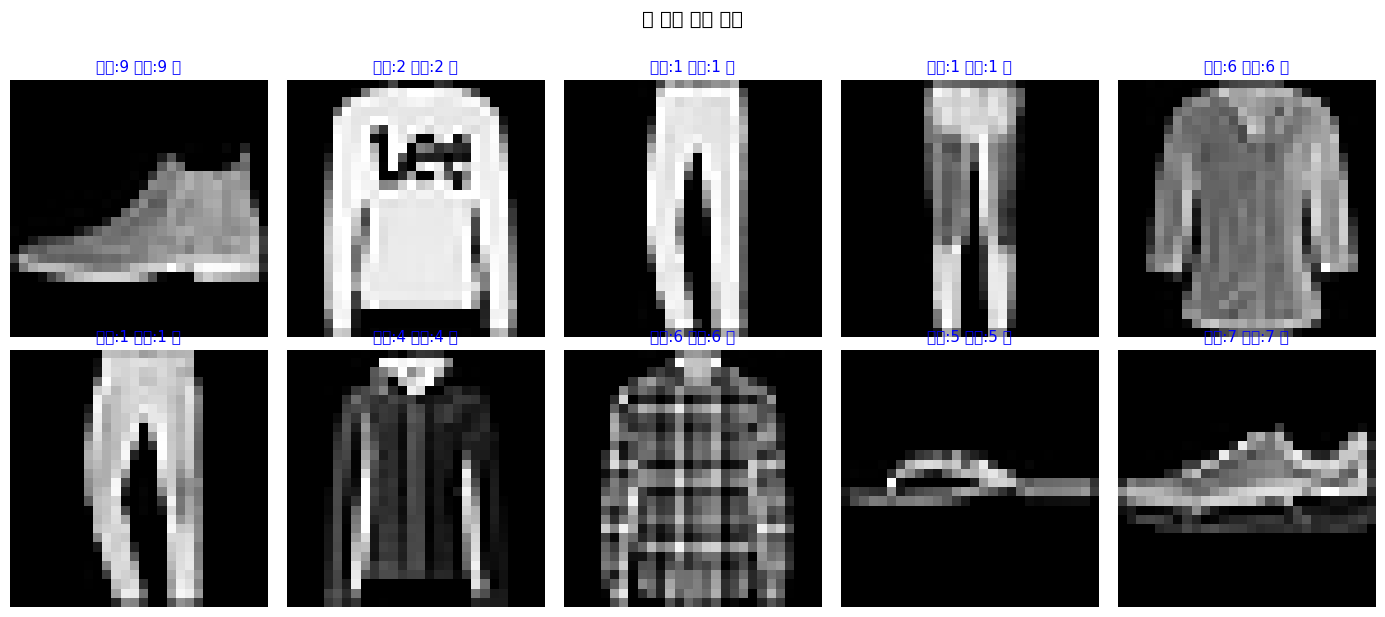

파란색 = 맞춤 ✅ / 빨간색 = 틀림 ❌


In [71]:
# ============================================================
# 🔍 예측 결과 시각화
# ============================================================

# 테스트 데이터에서 한 배치(64장) 꺼내기
examples = iter(test_loader)          # 반복자(iterator) 생성
images, labels = next(examples)       # 첫 번째 배치 가져오기
images = images.to(device)
labels = labels.to(device)

# 모델로 예측
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)  # 예측 숫자 추출

# ─── 10장 골라서 그림 그리기 ───
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i in range(10):
    # 2행 5열 배치: i를 행(row)과 열(col)로 변환
    row = i // 5    # 0~4는 0행, 5~9는 1행
    col = i % 5     # 0~4 반복
    ax = axes[row][col]

    # .cpu()    : GPU에 있는 텐서를 CPU로 가져옴
    #             (matplotlib은 CPU 텐서만 표시 가능)
    # .squeeze(): 불필요한 차원 제거 (1×28×28 → 28×28)
    ax.imshow(images[i].cpu().squeeze(), cmap='gray')

    # 정답과 예측 가져오기
    true_label = labels[i].item()    # 실제 정답
    pred_label = preds[i].item()     # 모델의 예측

    # 맞으면 파란색, 틀리면 빨간색으로 표시
    if true_label == pred_label:
        color = 'blue'
        result = '✅'
    else:
        color = 'red'
        result = '❌'

    ax.set_title(
        f"정답:{true_label} 예측:{pred_label} {result}",
        color=color,
        fontsize=11
    )
    ax.axis('off')  # 축 눈금 숨기기

plt.suptitle('🔍 모델 예측 결과', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("파란색 = 맞춤 ✅ / 빨간색 = 틀림 ❌")

---
## 🧪 Step 10. (보너스) 내가 직접 숫자 그려서 테스트하기

Colab에서 직접 마우스로 숫자를 그려서 모델에 넣어보자!

In [13]:
# ============================================================
# 🧪 직접 그린 숫자로 테스트하기
# ============================================================
# 마우스로 숫자를 그리면 모델이 맞춰봅니다!
#
# 사용법:
#   1. 이 셀을 실행하면 아래에 검은 캔버스가 나타남
#   2. 마우스로 숫자를 그리기 (흰색 선으로 그려짐)
#   3. "예측하기" 버튼 클릭 → 모델이 어떤 숫자인지 맞춤!
#   4. "지우기" 버튼으로 캔버스를 초기화할 수 있음
# ============================================================

from IPython.display import HTML, display
from google.colab import output
import numpy as np
from PIL import Image
import io, base64

# --- 그린 이미지를 받아서 모델에 넣는 함수 ---
def predict_drawing(image_data):
    """
    캔버스에서 그린 이미지(base64)를 받아서
    28×28으로 축소 → 모델에 넣어 예측 결과 출력
    """
    # base64 문자열에서 이미지 데이터만 추출
    image_data = image_data.split(',')[1]
    image_bytes = base64.b64decode(image_data)

    # 이미지 열기 → 흑백 변환 → 28×28로 리사이즈
    img = Image.open(io.BytesIO(image_bytes)).convert('L').resize((28, 28))

    # numpy 배열로 변환 → 0~1 범위로 정규화
    img_array = np.array(img) / 255.0

    # MNIST 전처리와 동일하게 정규화
    img_array = (img_array - 0.5) / 0.5

    # PyTorch 텐서로 변환 (배치×채널×높이×너비 형태)
    img_tensor = torch.FloatTensor(img_array).unsqueeze(0).unsqueeze(0).to(device)

    # 모델로 예측
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.softmax(output, dim=1)  # 확률로 변환
        predicted = torch.argmax(output, dim=1).item()
        confidence = probabilities[0][predicted].item() * 100

    print(f"\n🤖 모델 예측: {predicted} (확신도: {confidence:.1f}%)")
    print(f"\n각 숫자일 확률:")
    for i in range(10):
        bar = '█' * int(probabilities[0][i].item() * 30)
        print(f"  {i}: {probabilities[0][i].item()*100:5.1f}% {bar}")

# 자바스크립트에서 파이썬 함수를 호출할 수 있도록 등록
output.register_callback('notebook.predict_drawing', predict_drawing)

# --- 캔버스 UI (HTML + JavaScript) ---
canvas_html = """
<div style="text-align:center">
  <h3>✏️ 아래 검은 영역에 숫자를 그려보세요!</h3>
  <canvas id="drawCanvas" width="280" height="280"
    style="border:3px solid #4285f4; background:black; cursor:crosshair; border-radius:8px;">
  </canvas>
  <br><br>
  <button onclick="predictDrawing()"
    style="padding:10px 30px; font-size:16px; background:#4285f4; color:white;
           border:none; border-radius:6px; cursor:pointer; margin-right:10px;">
    🤖 예측하기
  </button>
  <button onclick="clearCanvas()"
    style="padding:10px 30px; font-size:16px; background:#ea4335; color:white;
           border:none; border-radius:6px; cursor:pointer;">
    🗑️ 지우기
  </button>
  <p style="color:gray; font-size:13px; margin-top:10px;">
    💡 팁: 캔버스 중앙에 크게 그려야 잘 인식됩니다!
  </p>
</div>

<script>
  var canvas = document.getElementById('drawCanvas');
  var ctx = canvas.getContext('2d');
  var drawing = false;

  // 선 스타일 설정 (흰색, 굵기 18)
  ctx.strokeStyle = 'white';
  ctx.lineWidth = 18;
  ctx.lineCap = 'round';
  ctx.lineJoin = 'round';

  canvas.addEventListener('mousedown', function(e) {
    drawing = true;
    ctx.beginPath();
    ctx.moveTo(e.offsetX, e.offsetY);
  });

  canvas.addEventListener('mousemove', function(e) {
    if (drawing) {
      ctx.lineTo(e.offsetX, e.offsetY);
      ctx.stroke();
    }
  });

  canvas.addEventListener('mouseup', function() { drawing = false; });
  canvas.addEventListener('mouseout', function() { drawing = false; });

  // 터치 지원 (모바일/태블릿)
  canvas.addEventListener('touchstart', function(e) {
    e.preventDefault();
    drawing = true;
    var touch = e.touches[0];
    var rect = canvas.getBoundingClientRect();
    ctx.beginPath();
    ctx.moveTo(touch.clientX - rect.left, touch.clientY - rect.top);
  });

  canvas.addEventListener('touchmove', function(e) {
    e.preventDefault();
    if (drawing) {
      var touch = e.touches[0];
      var rect = canvas.getBoundingClientRect();
      ctx.lineTo(touch.clientX - rect.left, touch.clientY - rect.top);
      ctx.stroke();
    }
  });

  canvas.addEventListener('touchend', function() { drawing = false; });

  function clearCanvas() {
    ctx.fillStyle = 'black';
    ctx.fillRect(0, 0, canvas.width, canvas.height);
  }

  function predictDrawing() {
    var dataURL = canvas.toDataURL('image/png');
    google.colab.kernel.invokeFunction('notebook.predict_drawing', [dataURL], {});
  }
</script>
"""

display(HTML(canvas_html))
print("⬆️ 위 캔버스에 숫자를 그리고 [예측하기] 버튼을 눌러보세요!")

⬆️ 위 캔버스에 숫자를 그리고 [예측하기] 버튼을 눌러보세요!


---

## 📝 실습 정리

### 오늘 배운 전체 흐름

```
📂 데이터 준비
  └→ MNIST 다운로드 & 전처리 (텐서 변환 + 정규화)

🏗️ 모델 설계
  └→ 입력(784) → 은닉층(256) → 은닉층(128) → 출력(10)

⚙️ 도구 설정
  └→ 손실 함수: CrossEntropyLoss
  └→ 옵티마이저: Adam (lr=0.001)

🏋️ 학습 (×10 에포크)
  └→ 순전파 → 손실 계산 → 역전파 → 가중치 업데이트

📊 평가
  └→ 테스트 데이터로 정확도 측정 (97%+ 달성!)
```

### 🚀 더 해보면 좋은 것들

- **CNN으로 바꿔보기**: `nn.Conv2d`를 사용하면 정확도 99%까지 올라간다!
- **학습률 바꿔보기**: `lr=0.01`, `lr=0.0001`로 바꾸면 학습 곡선이 어떻게 달라지나?
- **배치 사이즈 실험**: 16, 256 등으로 바꿔보며 속도와 정확도 비교
- **Fashion-MNIST 도전**: 같은 코드로 옷 종류(티셔츠, 바지, 운동화 등) 분류해 보기
  - `datasets.MNIST` → `datasets.FashionMNIST`로만 바꾸면 됨!